In [ ]:
# from github saadarshad102/Sentiment-Analysis-CNN

import numpy as np
import random as rn

sd = 0 # Here sd means seed.
np.random.seed(sd)
rn.seed(sd)

import string
import re
import matplotlib.pyplot as plt
from nltk import word_tokenize
import gensim
import pandas as pd
from gensim import models
from keras import regularizers, optimizers
from tensorflow.python.keras.layers import Embedding, Input, concatenate, Dropout, Dense, Reshape, Flatten, Conv1D, GlobalMaxPooling1D, \
    Conv2D, MaxPooling2D, MaxPooling1D, GlobalMaxPooling2D, Concatenate
from keras.models import Model, load_model
from keras.optimizers import Adam
from keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
import numpy as np
from keras.preprocessing.sequence import pad_sequences
from keras.layers.core import Flatten
from keras.callbacks import ModelCheckpoint, EarlyStopping
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
file_location = '/content/drive/My Drive/Data Instagram/Labeled/'
file_location_test = '/content/drive/My Drive/Data Instagram/To be Labeled/'
# file_location_test = '/content/drive/My Drive/Data Instagram/Labeled/'
train_data_name = 'jokowimundurlahALL'
test_data_name = 'jokowimundurlahB2(5001-6000)'
data = pd.read_csv(file_location + train_data_name + '.csv', sep=';', encoding='latin-1')
data_test = pd.read_csv(file_location_test + test_data_name + '.csv', sep=';', encoding='latin-1')
# Comment = data['Comment']
# Label = data['Label']
print(data.head())
# print(Comment.head())
# print(Label.head())
print(data_test.head())

print(data.shape)
# print(Comment.shape)
# print(Label.shape)
print(data_test.head())

# print(data.Comment.value_counts())
print(data.Label.value_counts())

             Username  ... Label
0        ali_h_sangun  ...  Hate
1       supriatna2506  ...  Hate
2             w_d1982  ...  Hate
3       taudahlupagua  ...  Hate
4  rayhansimanjuntak7  ...  Hate

[5 rows x 4 columns]
           Username                          Comment             Target  Label
0  pelangi_air_mata               N_Target sabaaaaar       ['dayak162']    NaN
1  pelangi_air_mata                N_Target sabaaaar        ['kupanji']    NaN
2  pelangi_air_mata                 N_Target sabaaar    ['sesamaulida']    NaN
3  pelangi_air_mata  N_Target sabaaar Kok abng emosi   ['medanimedani']    NaN
4  pelangi_air_mata              N_Target sabaar bng  ['hanafiamische']    NaN
(3776, 4)
           Username                          Comment             Target  Label
0  pelangi_air_mata               N_Target sabaaaaar       ['dayak162']    NaN
1  pelangi_air_mata                N_Target sabaaaar        ['kupanji']    NaN
2  pelangi_air_mata                 N_Target sabaaar    ['s

In [ ]:
def remove_punct(text):
    # text_nopunct = ''
    text_nopunct = re.sub('[' + string.punctuation + ']', '', text)
    return text_nopunct


data['Comment_Clean'] = data['Comment'].apply(lambda x: remove_punct(x))
print(data['Comment_Clean'])

0                           Abu CABUL OTAK BELLENG BELENG
1                                             Abu bangsat
2                                  Abu gosok mana woooyyy
3       Ah China Sampah Doang Luh Di Indonesia Pulang ...
4       Akibat presidennya orang CINA Seolah indonesia...
                              ...                        
3771    Tinggal menunggu waktu aja ketuanya di kutuk j...
3772              Tinggal nunggu kehancuran negeri ku ini
3773                               Tinggal tunggu azabnya
3774    Woy Maling Maling Maling Bangsat Woy Bangsat B...
3775        dan bodohnya cebong masih banyak yang nyembah
Name: Comment_Clean, Length: 3776, dtype: object


**Tokenize and lowercase**

In [ ]:
tokens = [word_tokenize(sen) for sen in data['Comment_Clean']]
print(tokens)


def lower_token(tokens):
    return [w.lower() for w in tokens]


lower_tokens = [lower_token(token) for token in tokens]
print(lower_tokens)

[['Abu', 'CABUL', 'OTAK', 'BELLENG', 'BELENG'], ['Abu', 'bangsat'], ['Abu', 'gosok', 'mana', 'woooyyy'], ['Ah', 'China', 'Sampah', 'Doang', 'Luh', 'Di', 'Indonesia', 'Pulang', 'Sonoh', 'Luh'], ['Akibat', 'presidennya', 'orang', 'CINA', 'Seolah', 'indonesia', 'sudah', 'seperti', 'rumahnya', 'sendiri', 'Dan', 'pribumi', 'dianggap', 'seperti', 'sampah', 'Apa', 'kalian', 'ga', 'sadar', 'wahai', 'CEBONG'], ['Anis', 'kontol'], ['Anjing', 'Ngentt', 'emngnya', 'knapa', 'NTarget', 'NTarget'], ['Apa', 'kabar', 'ya', 'kolam', 'cebong', 'togog', 'kalau', 'mati', 'lampu', 'gini', 'jgn', 'mereka', 'ngap', 'ngapan', 'kehabisan', 'oksegen'], ['Apaaaa', 'tahu', 'Penguasa', 'Dzalim', 'tp', 'km', 'membiarkannya', 'Dzalim', 'dengan', 'mengatas', 'namakan', 'Rakyat', 'makmur', 'Justru', 'dengan', 'yg', 'dilakukan', 'Pak', 'Prabowo', 'adalah', 'mengundang', 'Adzab', 'ALLAH', 'SWT'], ['Asbun', 'mulut', 'si', 'jaenudin', 'ini'], ['Aseli', 'ga', 'faham', 'cara', 'berfikir', 'ini', 'orang', 'apa', 'mesti', 'dun

In [ ]:
stoplist = (open('/content/drive/My Drive/Data Instagram/Stopwords/tala-stopword.txt', 'r').read().replace('\n', ' ')).split(" ")

def removeStopWords(tokens):
    return [word for word in tokens if word not in stoplist]

filtered_words = [removeStopWords(sen) for sen in lower_tokens]
# filtered_words = lower_tokens
data['Comment_Final'] = [' '.join(sen) for sen in filtered_words]
data['tokens'] = filtered_words
print(data['Comment_Final'])
print(data['tokens'])

0                           abu cabul otak belleng beleng
1                                             abu bangsat
2                                       abu gosok woooyyy
3          ah china sampah luh indonesia pulang sonoh luh
4       akibat presidennya orang cina indonesia rumahn...
                              ...                        
3771    tinggal menunggu ketuanya kutuk batu sesuai pe...
3772                     tinggal nunggu kehancuran negeri
3773                               tinggal tunggu azabnya
3774    woy maling maling maling bangsat woy bangsat b...
3775                              bodohnya cebong nyembah
Name: Comment_Final, Length: 3776, dtype: object
0                     [abu, cabul, otak, belleng, beleng]
1                                          [abu, bangsat]
2                                   [abu, gosok, woooyyy]
3       [ah, china, sampah, luh, indonesia, pulang, so...
4       [akibat, presidennya, orang, cina, indonesia, ...
                       

In [ ]:
Not_Hate = []
Hate = []
for l in data['Label']:
    if l == 'Not_Hate':
        Not_Hate.append(1)
        Hate.append(0)
        # neg.append(1)
    elif l == 'Hate':
        Not_Hate.append(0)
        # pos.append(1)
        Hate.append(1)

data['Not_Hate'] = Not_Hate
print(data['Not_Hate'])
data['Hate'] = Hate
print(data['Hate'])

data = data[['Comment_Final', 'tokens', 'Label', 'Not_Hate', 'Hate']]
data.head()
print(data.head())

# data_train, data_eval = train_test_split(data, test_size=0.20, random_state=100)
# print(data_train)
# print(data_eval)

0       0
1       0
2       0
3       0
4       0
       ..
3771    1
3772    1
3773    1
3774    1
3775    0
Name: Not_Hate, Length: 3776, dtype: int64
0       1
1       1
2       1
3       1
4       1
       ..
3771    0
3772    0
3773    0
3774    0
3775    1
Name: Hate, Length: 3776, dtype: int64
                                       Comment_Final  ... Hate
0                      abu cabul otak belleng beleng  ...    1
1                                        abu bangsat  ...    1
2                                  abu gosok woooyyy  ...    1
3     ah china sampah luh indonesia pulang sonoh luh  ...    1
4  akibat presidennya orang cina indonesia rumahn...  ...    1

[5 rows x 5 columns]


In [ ]:
all_training_words = [word for tokens in data['tokens'] for word in tokens]
training_sentence_lengths = [len(tokens) for tokens in data['tokens']]
TRAINING_VOCAB = sorted(list(set(all_training_words)))
print("%s words total, with a vocabulary size of %s" % (len(all_training_words), len(TRAINING_VOCAB)))
print("Max sentence length is %s" % max(training_sentence_lengths))
print("ALL TRAINING WORDS: \n", all_training_words)
# all_test_words = [word for tokens in data_eval["tokens"] for word in tokens]
# test_sentence_lengths = [len(tokens) for tokens in data_eval["tokens"]]
# TEST_VOCAB = sorted(list(set(all_test_words)))
# print("%s words total, with a vocabulary size of %s" % (len(all_test_words), len(TEST_VOCAB)))
# print("Max sentence length is %s" % max(test_sentence_lengths))

22113 words total, with a vocabulary size of 7126
Max sentence length is 139
ALL TRAINING WORDS: 
 ['abu', 'cabul', 'otak', 'belleng', 'beleng', 'abu', 'bangsat', 'abu', 'gosok', 'woooyyy', 'ah', 'china', 'sampah', 'luh', 'indonesia', 'pulang', 'sonoh', 'luh', 'akibat', 'presidennya', 'orang', 'cina', 'indonesia', 'rumahnya', 'pribumi', 'dianggap', 'sampah', 'sadar', 'cebong', 'anis', 'kontol', 'anjing', 'ngentt', 'emngnya', 'knapa', 'ntarget', 'ntarget', 'kabar', 'ya', 'kolam', 'cebong', 'togog', 'mati', 'lampu', 'gini', 'ngap', 'ngapan', 'kehabisan', 'oksegen', 'apaaaa', 'penguasa', 'dzalim', 'km', 'membiarkannya', 'dzalim', 'mengatas', 'namakan', 'rakyat', 'makmur', 'prabowo', 'mengundang', 'adzab', 'allah', 'swt', 'asbun', 'mulut', 'jaenudin', 'aseli', 'faham', 'berfikir', 'orang', 'mesti', 'dungu', 'ngerti', 'ebong', 'astaghfirullah', 'pakdhe', 'raja', 'maling', 'ntarget', 'tumaannn', 'banser', 'meong', 'badai', 'barunya', 'people', 'poweeeeeer', 'hei', 'rakyat', 'terdzolimin', 't

Word2Vec(vocab=7126, size=100, alpha=0.025)


/usr/local/lib/python3.6/dist-packages/smart_open/smart_open_lib.py:410: UserWarning: This function is deprecated, use smart_open.open instead. See the migration notes for details: https://github.com/RaRe-Technologies/smart_open/blob/master/README.rst#migrating-to-the-new-open-function
  'See the migration notes for details: %s' % _MIGRATION_NOTES_URL
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:10: DeprecationWarning: Call to deprecated `__getitem__` (Method will be removed in 4.0.0, use self.wv.__getitem__() instead).
  # Remove the CWD from sys.path while we load stuff.


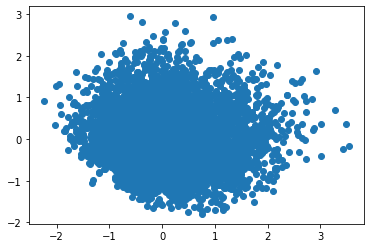

/usr/local/lib/python3.6/dist-packages/smart_open/smart_open_lib.py:410: UserWarning: This function is deprecated, use smart_open.open instead. See the migration notes for details: https://github.com/RaRe-Technologies/smart_open/blob/master/README.rst#migrating-to-the-new-open-function
  'See the migration notes for details: %s' % _MIGRATION_NOTES_URL
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:29: DeprecationWarning: Call to deprecated `__contains__` (Method will be removed in 4.0.0, use self.wv.__contains__() instead).
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:29: DeprecationWarning: Call to deprecated `__getitem__` (Method will be removed in 4.0.0, use self.wv.__getitem__() instead).


Word2Vec(vocab=7126, size=100, alpha=0.025)
Found 7126 unique tokens.
[[   0    0    0 ...  226 2663 2664]
 [   0    0    0 ...    0  412   83]
 [   0    0    0 ...  412 2665 2666]
 ...
 [   0    0    0 ...  253  174  871]
 [   0    0    0 ... 1548  207    5]
 [   0    0    0 ...    0 7125   13]]
(7127, 100)


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:59: DeprecationWarning: Call to deprecated `__contains__` (Method will be removed in 4.0.0, use self.wv.__contains__() instead).
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:59: DeprecationWarning: Call to deprecated `__getitem__` (Method will be removed in 4.0.0, use self.wv.__getitem__() instead).


In [ ]:
# MODEL WORD2VEC
EMBEDDING_DIM = 100
dsample = 1e-3
w2v_model = gensim.models.Word2Vec(data['tokens'], size=EMBEDDING_DIM, min_count=1, sg=1, window=10, workers=1, iter=100, seed=sd)
print(w2v_model)
w2v_model.save('./Word2Vec.bin')

from sklearn.decomposition import PCA
from matplotlib import pyplot

X = w2v_model[w2v_model.wv.vocab]
pca = PCA(n_components=2)
result = pca.fit_transform(X)

pyplot.scatter(result[:, 0], result[:, 1])
# words = list(w2v_model.wv.vocab)
# for i, word in enumerate(words):
# 	pyplot.annotate(word, xy=(result[i, 0], result[i, 1]))
pyplot.show()

word2vec_path = 'Word2Vec.bin'
word2vec = models.KeyedVectors.load(word2vec_path)
print(word2vec)


def get_average_word2vec(tokens_list, vector, generate_missing=False, k=EMBEDDING_DIM):
    if len(tokens_list) < 1:
        return np.zeros(k)
    if generate_missing:
        vectorized = [vector[word] if word in vector else np.random.rand(k) for word in tokens_list]
    else:
        vectorized = [vector[word] if word in vector else np.zeros(k) for word in tokens_list]
    length = len(vectorized)
    summed = np.sum(vectorized, axis=0)
    averaged = np.divide(summed, length)
    return averaged


def get_word2vec_embeddings(vectors, clean_comments, generate_missing=False):
    embeddings = clean_comments['tokens'].apply(
        lambda x: get_average_word2vec(x, vectors, generate_missing=generate_missing))
    return list(embeddings)


training_embeddings = get_word2vec_embeddings(word2vec, data, generate_missing=True)

MAX_SEQUENCE_LENGTH = max(training_sentence_lengths) #DEFAULT NUMBER 0..253 etc
tokenizer = Tokenizer(num_words=len(TRAINING_VOCAB), lower=True, char_level=False)
tokenizer.fit_on_texts(data["Comment_Final"].tolist())
training_sequences = tokenizer.texts_to_sequences(data["Comment_Final"].tolist())

train_word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(train_word_index))

train_cnn_data = pad_sequences(training_sequences, maxlen=MAX_SEQUENCE_LENGTH)
print(train_cnn_data)

train_embedding_weights = np.zeros((len(train_word_index) + 1, EMBEDDING_DIM))
for word, index in train_word_index.items():
    train_embedding_weights[index, :] = word2vec[word] if word in word2vec else np.random.rand(EMBEDDING_DIM)
print(train_embedding_weights.shape)

# test_sequences = tokenizer.texts_to_sequences(data_eval["Comment_Final"].tolist())
# test_cnn_data = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH)

**CNN Model**

In [ ]:
from keras.layers import BatchNormalization

def Conv1DNet(embeddings, max_sequence_length, num_words, embedding_dim, labels_index):
    embedding_layer = Embedding(num_words,
                                embedding_dim,
                                weights=[embeddings],
                                input_length=max_sequence_length,
                                trainable=False)

    sequence_input = Input(shape=(max_sequence_length,), dtype='int32')
    embedded_sequences = embedding_layer(sequence_input)

    convs = []
    filter_sizes = [2, 3, 4, 5, 6]
    num_filters = 200 #default 200

    for filter_size in filter_sizes:
        l_conv = Conv1D(filters=num_filters, kernel_size=filter_size, activation='relu')(embedded_sequences)
        l_pool = GlobalMaxPooling1D()(l_conv)
        convs.append(l_pool)

    l_merge = concatenate(convs, axis=1)

    drops1 = Dropout(0.1,seed=sd)(l_merge)
    dense = Dense(128, activation='relu')(drops1) #default 128
    drops2 = Dropout(0.2,seed=sd)(dense) #default 0.2
    preds = Dense(labels_index, activation='sigmoid')(drops2)  # default sigmoid
    import tensorflow as tf
    model = tf.compat.v1.keras.Model(sequence_input, preds)
    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['acc'])
    model.summary()
    return model

def Conv1DNetTes(embeddings, max_sequence_length, num_words, embedding_dim, labels_index):
    embedding_layer = Embedding(num_words,
                                embedding_dim,
                                weights=[embeddings],
                                input_length=max_sequence_length,
                                trainable=True)

    sequence_input = Input(shape=(max_sequence_length,), dtype='int32')
    embedded_sequences = embedding_layer(sequence_input)

    convs = []
    filter_sizes = [3, 4, 5]
    num_filters = 100 #default 200

    for filter_size in filter_sizes:
        l_conv = Conv1D(filters=num_filters, kernel_size=filter_size, activation='relu')(embedded_sequences)
        # bn = BatchNormalization()(l_conv)
        l_pool = GlobalMaxPooling1D()(l_conv)
        convs.append(l_pool)

    l_merge = concatenate(convs, axis=1)
    dense = Dense(128, activation='relu')(l_merge) #default 128
    preds = Dense(labels_index, activation='sigmoid')(dense)  # default sigmoid

    model = Model(sequence_input, preds)
    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['acc'])
    model.summary()
    return model

def Conv1DNet2(embeddings, max_sequence_length, num_words, embedding_dim, labels_index):
    embedding_layer = Embedding(num_words,
                                embedding_dim,
                                weights=[embeddings],
                                input_length=max_sequence_length,
                                trainable=True)

    sequence_input = Input(shape=(max_sequence_length,), dtype='int32')
    embedded_sequences = embedding_layer(sequence_input)

    convs = []
    filter_sizes = [3, 4, 5] #default 3,4,5
    num_filters = 200 #default 200

    for filter_size in filter_sizes:
        l_conv = Conv1D(filters=num_filters, kernel_size=filter_size, activation='relu', padding='same')(embedded_sequences)
        bn = BatchNormalization()(l_conv)
        l_pool = GlobalMaxPooling1D()(bn)
        convs.append(l_pool)

    l_merge = concatenate(convs, axis=1)
    drops1 = Dropout(0.1)(l_merge)
    dense = Dense(128, activation='relu')(drops1) #default 128
    drops2 = Dropout(0.1)(dense)
    preds = Dense(labels_index, activation='sigmoid')(drops2)  # default sigmoid

    model = Model(sequence_input, preds)
    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['acc'])
    model.summary()
    return model


def Conv1DNetv1(embeddings, max_sequence_length, num_words, embedding_dim, labels_index):
    embedding_layer = Embedding(num_words,
                                embedding_dim,
                                weights=[embeddings],
                                input_length=max_sequence_length,
                                trainable=True)

    convs = []
    filter_sizes = [3, 8]
    num_filters = 100
    drop1 = 0.8

    sequence_input = Input(shape=(max_sequence_length,), dtype='int32')
    embedded_sequences = embedding_layer(sequence_input)

    for filter_size in filter_sizes:
        conv = Conv1D(filters=num_filters,
                             kernel_size=filter_size,
                             padding="valid",
                             activation="relu",
                             strides=1)(embedded_sequences)
        conv = MaxPooling1D(pool_size=2)(conv)
        conv = Flatten()(conv)
        convs.append(conv)
    z = Concatenate()(convs) if len(convs) > 1 else convs[0]

    z = Dropout(drop1)(z)
    z = Dense(50, activation="relu")(z)
    preds = Dense(labels_index, activation="sigmoid")(z)

    model = Model(sequence_input, preds)
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["acc"])

    model.summary()
    return model

def Conv1DNetv2(embeddings, max_sequence_length, num_words, embedding_dim, labels_index):
    embedding_layer = Embedding(num_words,
                                embedding_dim,
                                weights=[embeddings],
                                input_length=max_sequence_length,
                                trainable=True)


    filter_sizes = 3
    num_filters = 32
    drop1 = 0.1

    sequence_input = Input(shape=(max_sequence_length,), dtype='int32')
    embedded_sequences = embedding_layer(sequence_input)

    conv = Conv1D(filters=num_filters, kernel_size=filter_sizes, padding="same", activation="relu")(embedded_sequences)
    convs = MaxPooling1D()(conv)
    convss = Flatten()(convs)
    z = Dense(250, activation="relu")(convss)
    preds = Dense(labels_index, activation="sigmoid")(z)

    model = Model(sequence_input, preds)
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["acc"])

    model.summary()
    return model

def Conv1Dhkhpub(embeddings, max_sequence_length, num_words, embedding_dim, labels_index):
    embedding_layer = Embedding(num_words,
                                embedding_dim,
                                weights=[embeddings],
                                input_length=max_sequence_length,
                                trainable=False)

    sequence_input = Input(shape=(max_sequence_length,), dtype='int32')
    embedded_sequences = embedding_layer(sequence_input)

    convs = []
    filter_sizes = [3,4,5]
    num_filters = 256
    # num_epochs = 10
    # batch_size = 64

    for filter_size in filter_sizes:
        conv = Conv1D(filters=num_filters,
                      kernel_size=filter_size,
                      padding='valid',
                      activation='relu')(embedded_sequences)
        dropout = Dropout(0.1)(conv)
        bn = BatchNormalization()(dropout)
        dropout = Dropout(0.1)(bn)
        pool = MaxPooling1D(pool_size=max_sequence_length - filter_size + 1)(dropout)
        convs.append(pool)
    # end of convolution layers

    conv_merge = concatenate(convs, axis=1) if len(convs) > 1 else convs[0]
    dropout = Dropout(0.1)(conv_merge)
    flatten = Flatten()(dropout)
    dropout = Dropout(0.1)(flatten)
    preds = Dense(labels_index, activation='sigmoid')(dropout)

    model = Model(sequence_input, preds)
    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['acc'])
    model.summary()
    return model

def Conv1Dfanway(embeddings, max_sequence_length, num_words, embedding_dim, labels_index):
    embedding_layer = Embedding(num_words,
                                embedding_dim,
                                weights=[embeddings],
                                input_length=max_sequence_length)


    #
    numerical_input = Input((1,), name="numerical_input")
    sequence_input = Input(shape=(max_sequence_length,), dtype='int32')
    embedded_sequences = embedding_layer(sequence_input)

    # level 1
    x_level1 = Conv1D(300, 3, activation='relu')(embedded_sequences)
    x_level1 = MaxPooling1D(5)(x_level1)
    x_level1 = Flatten()(x_level1)
    x_level1 = concatenate([x_level1, numerical_input])
    x_level1 = Dense(300, activation='relu')(x_level1)
    preds_level1 = Dense(4, activation='softmax', name="preds_level1")(x_level1)

    # level 2
    x_level2 = Conv1D(300, 4, activation='relu')(embedded_sequences)
    x_level2 = MaxPooling1D(5)(x_level2)
    x_level2 = Flatten()(x_level2)
    x_level2 = concatenate([x_level2, numerical_input])
    x_level2 = Dense(300, activation='relu')(x_level2)
    preds_level2 = Dense(23, activation='softmax', name="preds_level2")(x_level2)

    # level 3
    x_level3 = Conv1D(300, 5, activation='relu')(embedded_sequences)
    x_level3 = MaxPooling1D(5)(x_level3)
    x_level3 = Flatten()(x_level3)
    x_level3 = concatenate([x_level3, numerical_input])
    x_level3 = Dense(300, activation='relu')(x_level3)
    preds_level3 = Dense(45, activation='softmax', name="preds_level3")(x_level3)

    # level 4
    x_level4 = Conv1D(300, 6, activation='relu')(embedded_sequences)
    x_level4 = MaxPooling1D(5)(x_level4)
    x_level4 = Flatten()(x_level4)
    x_level4 = concatenate([x_level4, numerical_input])
    x_level4 = Dense(300, activation='relu')(x_level4)
    preds_level4 = Dense(8, activation='softmax', name="preds_level4")(x_level4)

    # final layer
    x_final = concatenate([preds_level1, preds_level2, preds_level3, preds_level4])
    #x_final = Dense(4, activation='relu')(x_final)
    x_final = Dense(54, activation="softmax", name="x_final")(x_final)

    model = Model(inputs=[sequence_input, numerical_input], outputs=[preds_level1, preds_level2, preds_level3, preds_level4, x_final])
    model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["acc"])

    model.summary()
    return model

def Conv2DNet(embeddings, max_sequence_length, num_words, embedding_dim, labels_index):
    embedding_layer = Embedding(num_words,
                                embedding_dim,
                                weights=[embeddings],
                                input_length=max_sequence_length,
                                trainable=True)

    sequence_input = Input(shape=(max_sequence_length,), dtype='int32')
    embedded_sequences = embedding_layer(sequence_input)
    reshape = Reshape((max_sequence_length, embedding_dim, 1))(embedded_sequences)

    convs = []
    filter_sizes = [3, 4, 5]
    num_filters = 100 #default 200
    drop = 0.5

    for filter_size in filter_sizes:
        conv = Conv2D(filters=num_filters, kernel_size=filter_size, activation='relu',
                        kernel_regularizer=regularizers.l2(0.01))(reshape)
        pool = MaxPooling2D((max_sequence_length - filter_size + 1, 1), strides=(1, 1))(conv)
        flat = Flatten()(pool)
        convs.append(flat)

    concat = Concatenate()(convs) if len(convs) > 1 else convs[0]
    z = Dropout(drop)(concat)
    preds = Dense(labels_index, activation='softmax', kernel_regularizer=regularizers.l2(0.01))(z)

    model = Model(sequence_input, preds)
    adam = Adam(lr=1e-3)
    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['acc'])
    model.summary()
    return model

def Conv2DNet2(embeddings, max_sequence_length, num_words, embedding_dim, labels_index):
    embedding_layer = Embedding(num_words,
                                embedding_dim,
                                weights=[embeddings],
                                input_length=max_sequence_length,
                                trainable=True)

    sequence_input = Input(shape=(max_sequence_length,), dtype='int32')
    embedded_sequences = embedding_layer(sequence_input)
    reshape = Reshape((max_sequence_length, embedding_dim, 1))(embedded_sequences)

    convs = []
    filter_sizes = [3, 4, 5]
    num_filters = 200 #default 200
    drop = 0.1

    for filter_size in filter_sizes:
        conv = Conv2D(filters=num_filters, kernel_size=filter_size, activation='relu',
                        kernel_regularizer=regularizers.l2(0.01))(reshape)
        bn = BatchNormalization()(conv) #batch Normalization
        # drop = Dropout(drop)(bn)
        pool = MaxPooling2D((max_sequence_length - filter_size + 1, 1), strides=(1, 1))(bn)
        flat = Flatten()(pool)
        convs.append(flat)

    concat = Concatenate()(convs) if len(convs) > 1 else convs[0]
    z = Dropout(drop)(concat)
    preds = Dense(labels_index, activation='softmax', kernel_regularizer=regularizers.l2(0.01))(z)

    model = Model(sequence_input, preds)
    adam = Adam(lr=1e-3)
    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['acc'])
    model.summary()
    return model

def ConvKimYoon(embeddings, max_sequence_length, num_words, embedding_dim, labels_index):
    embedding_layer = Embedding(num_words,
                                embedding_dim,
                                weights=[embeddings],
                                input_length=max_sequence_length,
                                trainable=True)

    sequence_input = Input(shape=(max_sequence_length,), dtype='int32')
    embedded_sequences = embedding_layer(sequence_input)
    reshape = Reshape((max_sequence_length, embedding_dim, 1))(embedded_sequences)

    convs = []
    filter_sizes = [3,4,5]
    num_filters = 100
    drop = 0.5

    for filter_size in filter_sizes:
        conv = Conv2D(filters=num_filters, kernel_size=filter_size, activation='relu')(reshape)
        bn = BatchNormalization()(conv) #batch Normalization
        # drop = Dropout(drop)(bn)
        pool = MaxPooling2D((max_sequence_length - filter_size + 1, 1))(bn)
        flat = Flatten()(pool)
        convs.append(flat)

    concat = Concatenate()(convs) if len(convs) > 1 else convs[0]
    z = Dropout(drop)(concat)
    preds = Dense(labels_index, activation='softmax')(z)

    model = Model(sequence_input, preds)
    adadelta = optimizers.Adadelta()
    model.compile(loss='categorical_crossentropy',
                  optimizer=adadelta,
                  metrics=['acc'])
    model.summary()
    return model

def ConvKimYoonJverma(embeddings, max_sequence_length, num_words, embedding_dim, labels_index):
    embedding_layer = Embedding(num_words,
                                embedding_dim,
                                weights=[embeddings],
                                input_length=max_sequence_length,
                                trainable=True)

    sequence_input = Input(shape=(max_sequence_length,), dtype='int32')
    embedded_sequences = embedding_layer(sequence_input)
    reshape = Reshape((max_sequence_length, embedding_dim, 1))(embedded_sequences)

    convs = []
    filter_sizes = [5,4,3]
    num_filters = 100
    drop = 0.5
    # num_epochs = 25
    # batch_size = 50

    for filter_size in filter_sizes:
        conv = Conv2D(filters=num_filters, kernel_size=filter_size, activation='relu')(reshape)
        bn = BatchNormalization()(conv) #batch Normalization
        # drop = Dropout(drop)(bn)
        pool = MaxPooling2D((max_sequence_length - filter_size + 1, 1))(bn)
        flat = Flatten()(pool)
        convs.append(flat)

    concat = Concatenate()(convs) if len(convs) > 1 else convs[0]
    z = Dropout(drop)(concat)
    preds = Dense(labels_index, activation='softmax')(z)

    model = Model(sequence_input, preds)
    adadelta = optimizers.Adadelta()
    model.compile(loss='categorical_crossentropy',
                  optimizer=adadelta,
                  metrics=['acc'])
    model.summary()
    return model

def ConvBhaveshoswal(embeddings, max_sequence_length, num_words, embedding_dim, labels_index):
    embedding_layer = Embedding(num_words,
                                embedding_dim,
                                weights=[embeddings],
                                input_length=max_sequence_length,
                                trainable=True)

    sequence_input = Input(shape=(max_sequence_length,), dtype='int32')
    embedded_sequences = embedding_layer(sequence_input)
    reshape = Reshape((max_sequence_length, embedding_dim, 1))(embedded_sequences)

    convs = []
    filter_sizes = [3,4,5]
    num_filters = 512
    drop = 0.5
    # num_epochs = 100
    # batch_size = 32

    for filter_size in filter_sizes:
        conv = Conv2D(filters=num_filters, kernel_size=filter_size, padding='valid', kernel_initializer='normal', activation='relu')(reshape)
        pool = MaxPooling2D(pool_size=(max_sequence_length - filter_sizes[0] + 1, 1), strides=(1,1), padding='valid')(conv)
        convs.append(pool)

    concat = Concatenate()(convs) if len(convs) > 1 else convs[0]
    flat = Flatten()(concat)
    z = Dropout(drop)(flat)
    preds = Dense(units=2, activation='softmax')(z)

    model = Model(sequence_input, preds)
    adadelta = optimizers.Adadelta()
    model.compile(loss='binary_crossentropy',
                  optimizer=adadelta,
                  metrics=['acc'])
    model.summary()
    return model


Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_5 (InputLayer)            [(None, 139)]        0                                            
__________________________________________________________________________________________________
embedding_4 (Embedding)         (None, 139, 100)     712700      input_5[0][0]                    
__________________________________________________________________________________________________
conv1d_20 (Conv1D)              (None, 138, 200)     40200       embedding_4[0][0]                
__________________________________________________________________________________________________
conv1d_21 (Conv1D)              (None, 137, 200)     60200       embedding_4[0][0]                
____________________________________________________________________________________________

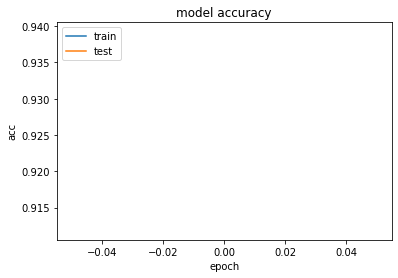

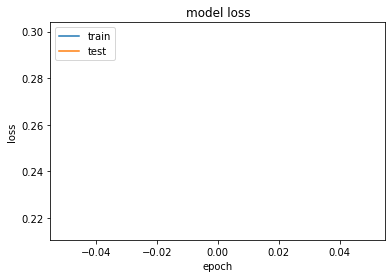

In [ ]:
# MODEL Train
label_names = ['Not_Hate', 'Hate']

x = train_cnn_data
y = data[label_names].values

num_epochs = 1
batch_size = 32

#Conv1DNet, Conv1DNet2(Conv1DNet with batchnormalization), Conv1DNetv1, Conv1DNetv2, Conv2DNet, Conv2DNet2(Conv2DNet with batchnormalization)
model = Conv1DNet(train_embedding_weights, MAX_SEQUENCE_LENGTH, len(train_word_index) + 1, EMBEDDING_DIM, len(list(label_names)))

# checkpoint
# filepath="weights.best.hdf5"
# earlystopping = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=200)
# checkpoint = ModelCheckpoint(filepath, monitor='val_acc', verbose=1, save_best_only=False, mode='max')
# callbacks_list = [earlystopping, checkpoint]

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=sd, stratify=y)

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# scaler.fit(x_train)
# x_train = scaler.transform(x_train)
# x_val = scaler.transform(x_val)

# early_stopping = EarlyStopping(monitor='val_loss', patience=0, verbose=1, mode='auto')
hist = model.fit(x_train, y_train, epochs=num_epochs, validation_data=(x_val, y_val),
                 batch_size=batch_size, verbose=1)#, callbacks=[early_stopping])

loss, acc = model.evaluate(x_train, y_train)
print("")
print('Training set loss:', loss)
print('Training set accuracy:', acc)

loss, acc = model.evaluate(x_val, y_val)
print("")
print('Validation set loss:', loss)
print('Validation set accuracy:', acc)

history = []
history.append(hist.history)

model.save('jokowimundurlahtraining.h5')

def get_avg(histories, his_key):
    tmp = []
    for history in histories:
        tmp.append(history[his_key][np.argmin(history['val_loss'])])
    return np.mean(tmp)

# print('Training: \t%0.4f loss / %0.4f acc' % (get_avg(history, 'loss'), get_avg(history, 'acc')))
# print('Validation: \t%0.4f loss / %0.4f acc' % (get_avg(history, 'val_loss'), get_avg(history, 'val_acc')))

# list all data in history
print(hist.history.keys())
# summarize history for accuracy
plt.plot(hist.history['acc'])
plt.plot(hist.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('acc')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
# TEST with REAL DATA

# all_test_words = [word for tokens in data_eval["tokens"] for word in tokens]
# test_sentence_lengths = [len(tokens) for tokens in data_eval["tokens"]]
# TEST_VOCAB = sorted(list(set(all_test_words)))
# print("%s words total, with a vocabulary size of %s" % (len(all_test_words), len(TEST_VOCAB)))
# print("Max sentence length is %s" % max(test_sentence_lengths))

# saved_model = load_model(filepath)

test_cnn_data = pad_sequences(tokenizer.texts_to_sequences(data_test['Comment']), maxlen=MAX_SEQUENCE_LENGTH)
predictions = model.predict(test_cnn_data, verbose=0)  # default 1024

labels = ['Not_Hate', 'Hate']
prediction_labels = []
for p in predictions:
    prediction_labels.append(labels[np.argmax(p)])

data_pred = pd.DataFrame(zip(data_test['Target'], prediction_labels), columns=['Target', 'Label'],
                         index=data_test['Comment'])
print(data_pred)

real_test_evaluation = model.evaluate(test_cnn_data, predictions)
print("\nLoss of real data test: ", real_test_evaluation[0])
print("\nAccuracy of real data test: ", real_test_evaluation[1])

result_file_location = '/content/drive/My Drive/Data Instagram/To be Labeled/using CNN/Result/'
data_pred.to_csv(result_file_location + test_data_name + 's.csv', sep=';')
# sum(data_test.Label == prediction_labels) / len(prediction_labels)
# data_test.Label.value_counts()

                                                               Target     Label
Comment                                                                        
N_Target sabaaaaar                                       ['dayak162']  Not_Hate
N_Target sabaaaar                                         ['kupanji']  Not_Hate
N_Target sabaaar                                      ['sesamaulida']  Not_Hate
N_Target sabaaar Kok abng emosi                      ['medanimedani']  Not_Hate
N_Target sabaar bng                                 ['hanafiamische']  Not_Hate
...                                                               ...       ...
Presiden busuk                                               ['None']  Not_Hate
Presiden butuh legitimasi tp legitimasi ada dit...        ['prabowo']  Not_Hate
Presiden dongo N_Target loe denger ga si Apa budeg         ['jokowi']  Not_Hate
Presiden dunggu                                              ['None']  Not_Hate
Presiden ga berguna                     

In [ ]:
data_testu = pad_sequences(tokenizer.texts_to_sequences(
    ['Bangsat lu goblok lu banyak bacot aja pasti lgbt lu ya',
     'HArus bagaimana ini kan kita tidak tahu dia bangsat apa tidak',
     'N_Target papua laknat bodoh mati busuk jokodok bacot anjing bangsat',
     'harusnya lebih baik lagi',
     'mantap euy',
     'mancing mania mantap banget euy',
     'presiden paling geblek, kasian banget papua',
     'arah jalannya kok becek???',
     'Freeport becek',
     'aamiin',
     'tdk semua org bisa menjadi lebih baik',
     'jancuk N_target kalh lagi tolol gtu',
     'njinh wowo bacot mati aja udh kalh dr jokowi pun',
     'N_Target cebong',
     'N_Target lo yg gw bikin busuk loh Loh gerombolan lgbt yaa']), maxlen=MAX_SEQUENCE_LENGTH)

testu = model.predict(data_testu, verbose=0)

prediction_testu = []
for p in testu:
    prediction_testu.append(labels[np.argmax(p)])

# testu_eval = model.evaluate(data_testu,testu, batch_size=1024)
# print('\n testu', prediction_testu)
# print('\n testu loss: ',testu_eval[0])
# print('\n testu accuracy: ',testu_eval[1])